# Análisis Semántico con BERT




## Instalación

In [1]:
import subprocess, sys

paquetes = [
    'transformers',
    'torch',
    'gensim',
    'scikit-learn',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scipy',
]

for pkg in paquetes:
    res = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    estado = '✓' if res.returncode == 0 else '✗'
    print(f'  {estado} {pkg}')

print('\n✅ Instalación completada')

  ✓ transformers
  ✓ torch
  ✓ gensim
  ✓ scikit-learn
  ✓ pandas
  ✓ numpy
  ✓ matplotlib
  ✓ seaborn
  ✓ scipy

✅ Instalación completada


## Imports y configuración

In [2]:
import warnings, os
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.spatial.distance import cosine
import re

import torch
from transformers import BertTokenizer, BertModel, BertForMaskedLM, pipeline
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Dispositivo: GPU si disponible, sino CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports OK')
print(f'   Dispositivo PyTorch: {DEVICE}')

# Rutas
DATA      = Path('..') / 'data' / 'processed'
FIGS      = Path('..') / 'data' / 'figures'
MODELS    = Path('..') / 'data' / 'models'
for d in [FIGS, MODELS]:
    d.mkdir(parents=True, exist_ok=True)

# Estilo de gráficos
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']

print('   Rutas configuradas OK')

✅ Imports OK
   Dispositivo PyTorch: cpu
   Rutas configuradas OK


## Cargar y preparar el corpus

In [3]:
# Preferir lyrics_english.csv (generado por Notebook 1)
# Si no existe, usa lyrics_clean.csv directamente (también funciona)
ENGLISH_CSV  = DATA / 'lyrics_english.csv'
COMBINED_CSV = DATA / 'lyrics_combined.csv'
P1_CSV       = DATA / 'lyrics_clean.csv'

if ENGLISH_CSV.exists():
    df = pd.read_csv(ENGLISH_CSV)
    print(f'Cargado lyrics_english.csv → {len(df):,} canciones')
elif COMBINED_CSV.exists():
    df = pd.read_csv(COMBINED_CSV)
    if 'Language' in df.columns:
        df = df[df['Language'].isin(['en', 'unknown'])].copy()
    print(f'Cargado lyrics_combined.csv (filtrado inglés) → {len(df):,} canciones')
else:
    df = pd.read_csv(P1_CSV)
    print(f'Cargado lyrics_clean.csv → {len(df):,} canciones')
    print('   (Ejecuta 01_scraping.ipynb primero para el corpus enriquecido)')

# Limpieza
df = df.dropna(subset=['Lyrics', 'Genre']).copy()
df['Lyrics'] = df['Lyrics'].astype(str)
df = df[df['Lyrics'].str.len() > 50].reset_index(drop=True)

# Solo géneros con ≥ 20 canciones
generos_validos = df['Genre'].value_counts()
generos_validos = generos_validos[generos_validos >= 20].index.tolist()
df = df[df['Genre'].isin(generos_validos)].reset_index(drop=True)

print(f'\nDistribución de géneros:')
print(df['Genre'].value_counts().to_string())
print(f'\nTotal: {len(df):,} canciones | {df["Genre"].nunique()} géneros')

✅ Cargado lyrics_english.csv → 8,797 canciones

Distribución de géneros:
Genre
Rock          1507
Pop           1202
Hip-Hop       1053
Metal          910
Country        902
Electronic     741
Jazz           725
Indie          608
R&B            580
Folk           569

Total: 8,797 canciones | 10 géneros


In [4]:
# ─── Muestra estratificada (para evitar tiempos muy largos con BERT) ───────
# Ajusta MAX_POR_GENERO según la RAM/GPU de tu máquina:
#   CPU lenta  → 50
#   CPU normal → 100
#   GPU        → 200 o más

MAX_POR_GENERO = 100   # ← AJUSTA AQUÍ

df_sample = (
    df.groupby('Genre', group_keys=False)
      .apply(lambda x: x.sample(min(len(x), MAX_POR_GENERO), random_state=42))
      .reset_index(drop=True)
)

print(f'Muestra para BERT: {len(df_sample):,} canciones')
print(df_sample['Genre'].value_counts().to_string())

LYRICS  = df_sample['Lyrics'].tolist()
GENRES  = df_sample['Genre'].tolist()

le = LabelEncoder()
LABELS = le.fit_transform(GENRES)

Muestra para BERT: 1,000 canciones
Genre
Country       100
Electronic    100
Folk          100
Hip-Hop       100
Indie         100
Jazz          100
Metal         100
Pop           100
R&B           100
Rock          100


## Cargar BERT

In [5]:
# ┌──────────────────────────────────────────────────────────────────┐
# │  Inglés  → bert-base-uncased  (este notebook)                   │
# │  Español → dccuchile/bert-base-spanish-wwm-cased  (BETO)        │
# └──────────────────────────────────────────────────────────────────┘
MODEL_NAME = 'bert-base-uncased'

print(f'Cargando {MODEL_NAME}...')
print('(Primera vez: descarga ~420 MB)\n')

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model     = BertModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'BERT cargado en {DEVICE}')
print(f'   Parámetros  : {n_params:,}')
print(f'   Dim. output : {model.config.hidden_size}')

Cargando bert-base-uncased...
(Primera vez: descarga ~420 MB)



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7833.13it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BERT cargado en cpu
   Parámetros  : 109,482,240
   Dim. output : 768


In [6]:
# ─── Funciones de embedding ───────────────────────────────────────────────────

def bert_embedding(text: str, strategy: str = 'cls') -> np.ndarray:
    """
    Genera el embedding BERT de un texto.

    strategy='cls'  → vector del token [CLS]  (representación global)
    strategy='mean' → promedio de todos los tokens
    """
    inputs = tokenizer(
        text[:1000],           # Truncar para velocidad
        return_tensors='pt',
        truncation=True,
        max_length=512,
        padding='max_length',
    ).to(DEVICE)

    with torch.no_grad():
        out = model(**inputs)

    if strategy == 'cls':
        return out.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
    else:
        mask = inputs['attention_mask'].unsqueeze(-1).float()
        sumv = (out.last_hidden_state * mask).sum(dim=1)
        summ = mask.sum(dim=1).clamp(min=1e-9)
        return (sumv / summ).squeeze().cpu().numpy()


def bert_embeddings_batch(texts: list, batch_size: int = 16) -> np.ndarray:
    """Genera embeddings para una lista de textos mostrando progreso."""
    result = []
    n = len(texts)
    for i in range(0, n, batch_size):
        batch = texts[i:i + batch_size]
        result.extend([bert_embedding(t) for t in batch])
        done = min(i + batch_size, n)
        bar  = '█' * int(done/n*25) + '░' * (25 - int(done/n*25))
        print(f'  [{bar}] {done}/{n}', end='\r')
    print()
    return np.array(result)


def word_contextual_embedding(sentence: str, word: str) -> np.ndarray:
    """
    Embedding contextual de una PALABRA específica dentro de su oración.
    Devuelve el promedio de los sub-tokens correspondientes.
    """
    inputs = tokenizer(
        sentence, return_tensors='pt', truncation=True, max_length=128
    ).to(DEVICE)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    idxs = [
        i for i, tok in enumerate(tokens)
        if word.lower() in tok.lower().replace('##', '')
    ]

    with torch.no_grad():
        out = model(**inputs)

    hidden = out.last_hidden_state[0].cpu().numpy()
    if idxs:
        return hidden[idxs].mean(axis=0)
    return hidden.mean(axis=0)  # fallback: promedio total


# Prueba rápida
e = bert_embedding('hello world this is a test song lyric')
print(f'Función lista — embedding shape: {e.shape}')

✅ Función lista — embedding shape: (768,)


## Generar embeddings BERT para todo el corpus


In [7]:
BERT_FILE = MODELS / 'bert_embeddings.npy'
SAMPLE_FILE = MODELS / 'bert_corpus_sample.csv'

if BERT_FILE.exists():
    # Recargar si ya existen
    bert_embs = np.load(BERT_FILE)
    df_sample_saved = pd.read_csv(SAMPLE_FILE)
    # Verificar que coincide con la muestra actual
    if len(bert_embs) == len(df_sample):
        print(f'Embeddings cargados desde caché: {bert_embs.shape}')
    else:
        BERT_FILE.unlink()  # Invalidar caché
        print('Tamaño diferente, recalculando...')

if not BERT_FILE.exists():
    print(f'Generando embeddings BERT para {len(LYRICS)} canciones...')
    print(f'(Estimado en CPU: ~{len(LYRICS)//60} min)')
    bert_embs = bert_embeddings_batch(LYRICS, batch_size=8)
    np.save(BERT_FILE, bert_embs)
    df_sample.to_csv(SAMPLE_FILE, index=False)
    print(f'Embeddings guardados: {bert_embs.shape}')

print(f'Shape final: {bert_embs.shape}  → {bert_embs.shape[0]} canciones × {bert_embs.shape[1]} dimensiones')

Generando embeddings BERT para 1000 canciones...
(Estimado en CPU: ~16 min)
  [█████████████████████████] 1000/1000
✅ Embeddings guardados: (1000, 768)
Shape final: (1000, 768)  → 1000 canciones × 768 dimensiones


## Análisis de polisemia contextual

In [8]:
# Misma palabra, contextos completamente distintos por género
POLISEMIA = {
    'fire': [
        ('Rock',       'the guitar is on fire tonight we burn the stage down with sound'),
        ('Pop',        'your love set my heart on fire every time you smile at me'),
        ('Hip-Hop',    'we will fire back no retreat streets got us ready for war'),
        ('Metal',      'fire and brimstone rain from hell consuming all the light above'),
        ('Electronic', 'fire up the synth the bass drops hard in the club tonight'),
    ],
    'heart': [
        ('Pop',        'my heart beats faster when you hold me close under the stars'),
        ('Rock',       'heart of gold but soul of iron we fight until the bitter end'),
        ('Hip-Hop',    'put your heart in the hustle grind every day no days off ever'),
        ('Country',    'country roads leading back to where my heart will always belong'),
        ('R&B',        'your heart is all I need tonight baby stay right here with me'),
    ],
    'dark': [
        ('Metal',      'the darkness descends upon the earth consuming all that lives below'),
        ('Indie',      'dancing in the dark alone with thoughts of you still haunting me'),
        ('Folk',       'dark winter mornings walking through the fog to reach the old creek'),
        ('Electronic', 'dark room neon lights the beat drops hard into the midnight air'),
        ('Rock',       'dark times call for louder guitars we rise above the storm tonight'),
    ],
    'run': [
        ('Country',    'run through the fields of Georgia chasing sunsets every summer night'),
        ('Hip-Hop',    'run the block hustle hard they cannot stop us we are free'),
        ('Pop',        'run to you whenever I am lost you always find my way'),
        ('Rock',       'run from the system break the chains we will not stop today'),
        ('Folk',       'run along the riverbank the willows whispering your name so soft'),
    ],
    'low': [
        ('Jazz',       'feeling low tonight the trumpet cries for all the loves I lost'),
        ('Hip-Hop',    'lay low move smart the streets watching every single step tonight'),
        ('Electronic', 'drop it low the bass line shakes the walls of the whole club'),
        ('Country',    'low sun on the horizon cattle lowing softly as the day ends'),
        ('Folk',       'low voice by the fire telling stories that the old ones knew'),
    ],
}

# Calcular embeddings contextuales
print('Calculando embeddings contextuales para 5 palabras polisémicas...')
polisemia_embs = {}
for palabra, contextos in POLISEMIA.items():
    polisemia_embs[palabra] = []
    for genero, oracion in contextos:
        emb = word_contextual_embedding(oracion, palabra)
        polisemia_embs[palabra].append({'genero': genero, 'oracion': oracion, 'emb': emb})
    print(f'  ✓ "{palabra}" — {len(contextos)} contextos')

print('\nEmbeddings contextuales listos')

Calculando embeddings contextuales para 5 palabras polisémicas...
  ✓ "fire" — 5 contextos
  ✓ "heart" — 5 contextos
  ✓ "dark" — 5 contextos
  ✓ "run" — 5 contextos
  ✓ "low" — 5 contextos

✅ Embeddings contextuales listos


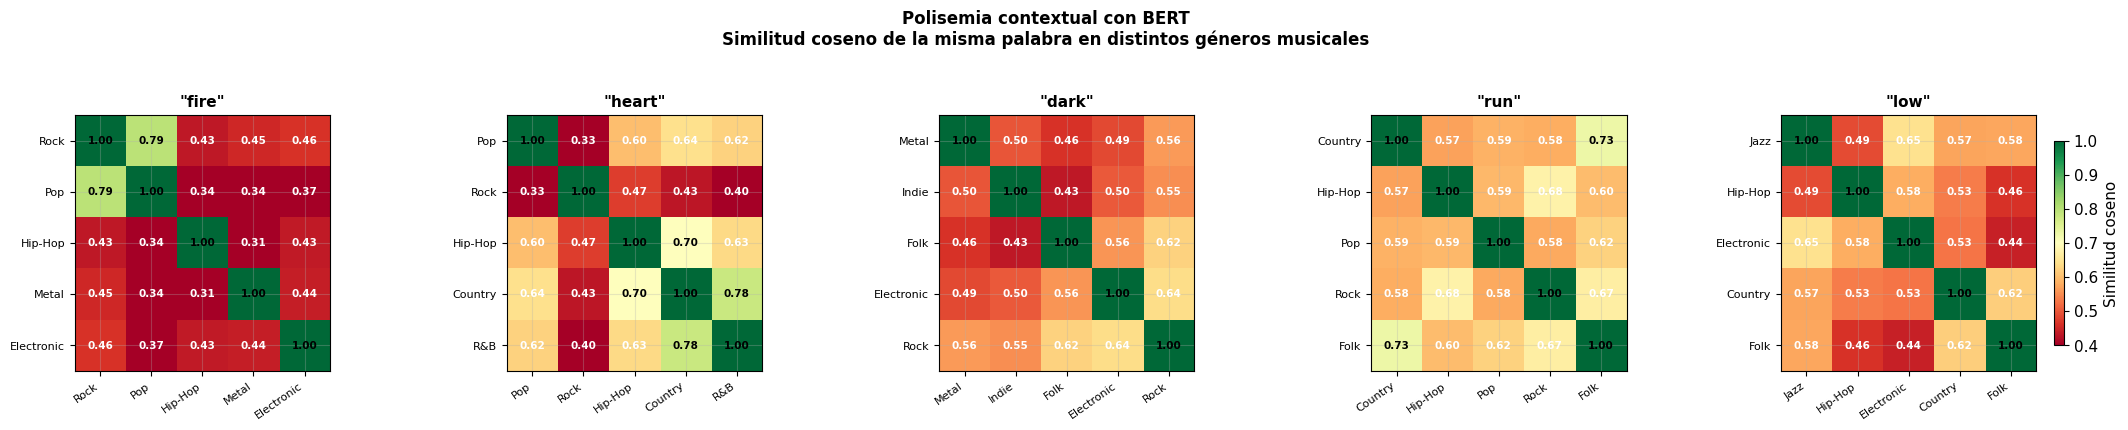

💡 Interpretación:
  Verde (≈1.0) → misma palabra, significado/uso SIMILAR en ambos géneros
  Rojo  (≈0.0) → misma palabra, significados MUY DIFERENTES por contexto
  → BERT detecta la diferencia; Word2Vec siempre daría el mismo vector


In [9]:
fig, axes = plt.subplots(1, len(POLISEMIA), figsize=(22, 4))

for ax, (palabra, resultados) in zip(axes, polisemia_embs.items()):
    n = len(resultados)
    sim = np.zeros((n, n))
    etiquetas = [r['genero'] for r in resultados]

    for i in range(n):
        for j in range(n):
            sim[i, j] = 1 - cosine(resultados[i]['emb'], resultados[j]['emb'])

    im = ax.imshow(sim, cmap='RdYlGn', vmin=0.4, vmax=1.0)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(etiquetas, rotation=35, ha='right', fontsize=8)
    ax.set_yticklabels(etiquetas, fontsize=8)
    ax.set_title(f'"{palabra}"', fontweight='bold', fontsize=11)

    for i in range(n):
        for j in range(n):
            color = 'white' if sim[i, j] < 0.7 else 'black'
            ax.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center',
                    fontsize=7.5, color=color, fontweight='bold')

plt.colorbar(im, ax=axes[-1], label='Similitud coseno', shrink=0.8)
plt.suptitle(
    'Polisemia contextual con BERT\n'
    'Similitud coseno de la misma palabra en distintos géneros musicales',
    fontsize=12, fontweight='bold', y=1.05
)
plt.tight_layout()
plt.savefig(FIGS / 'polisemia_bert.png', dpi=130, bbox_inches='tight')
plt.show()

print('Interpretación:')
print('  Verde (≈1.0) → misma palabra, significado/uso SIMILAR en ambos géneros')
print('  Rojo  (≈0.0) → misma palabra, significados MUY DIFERENTES por contexto')
print('  → BERT detecta la diferencia; Word2Vec siempre daría el mismo vector')

##  ¿Qué palabras predice BERT para completar frases típicas de cada género?


In [10]:
print('Cargando pipeline MLM (fill-mask)...')
mlm = pipeline(
    'fill-mask',
    model=MODEL_NAME,
    device=0 if torch.cuda.is_available() else -1,
)
print('Pipeline MLM listo\n')

# Frases representativas por género con máscara
MLM_FRASES = {
    'Rock':       'We will [MASK] the chains and rise above the pain tonight loud',
    'Pop':        'Your love makes my [MASK] beat faster every single time we meet',
    'Hip-Hop':    'Started from the [MASK] now the whole team is up grinding hard',
    'Metal':      'The [MASK] descends upon the earth consuming all the light above',
    'Country':    'Driving down the [MASK] road with nothing but the wind and stars',
    'Jazz':       'The [MASK] plays softly in the corner of the dimly lit room',
    'Electronic': 'Drop the [MASK] and let the whole crowd move to the rhythm now',
    'Indie':      'Wandering through the [MASK] fields alone searching for a quiet place',
    'R&B':        'Baby come a little [MASK] to me tonight under the city lights',
    'Folk':       'By the [MASK] fire we sang songs that our grandparents once knew',
}

# Filtrar solo géneros presentes en el corpus
MLM_FRASES = {g: f for g, f in MLM_FRASES.items() if g in generos_validos}

mlm_resultados = {}
print('=== Predicciones MLM de BERT por Género ===')
for genero, frase in MLM_FRASES.items():
    preds = mlm(frase, top_k=5)
    palabras  = [p['token_str'].strip() for p in preds]
    probs     = [p['score'] for p in preds]
    mlm_resultados[genero] = {'frase': frase, 'palabras': palabras, 'probs': probs}
    print(f'  {genero:<12} → {palabras}')

Cargando pipeline MLM (fill-mask)...


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 5875.11it/s]
BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Pipeline MLM listo

=== Predicciones MLM de BERT por Género ===
  Rock         → ['break', 'drop', 'release', 'wear', 'escape']
  Pop          → ['heart', 'blood', 'pulse', 'hearts', 'head']
  Hip-Hop      → ['start', 'beginning', 'back', 'top', 'bottom']
  Metal        → ['sun', 'moon', 'lord', 'god', 'spirit']
  Country      → ['country', 'dark', 'long', 'mountain', 'dirt']
  Jazz         → ['music', 'band', 'radio', 'piano', 'song']
  Electronic   → ['music', 'drum', 'guitar', 'microphone', 'drums']
  Indie        → ['open', 'wheat', 'empty', 'farm', 'corn']
  R&B          → ['closer', 'close', 'better', 'faster', 'nearer']
  Folk         → ['camp', 'cabin', 'old', 'barn', 'kitchen']


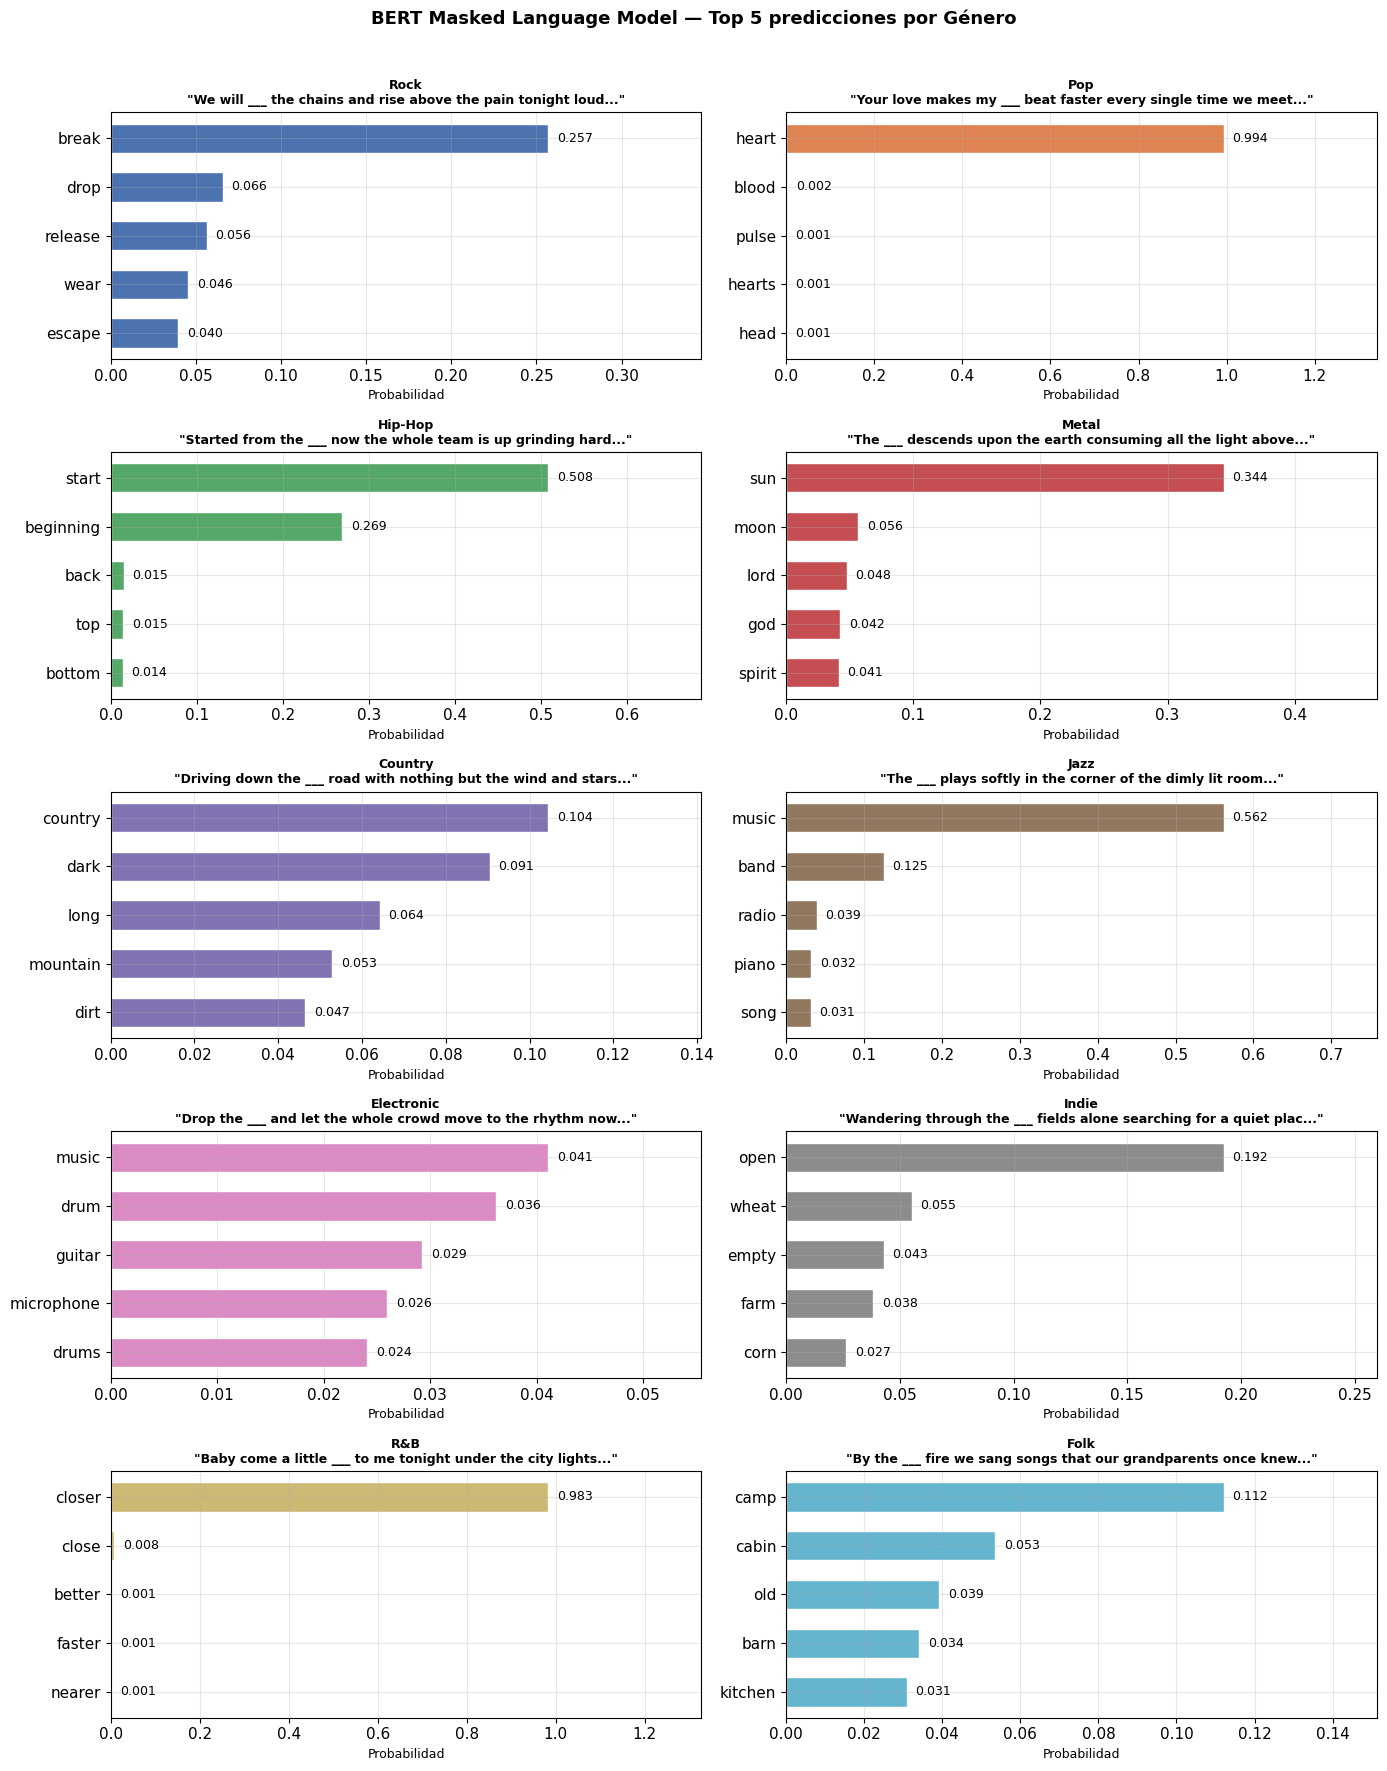

In [11]:
n_generos = len(MLM_FRASES)
cols = 2
rows = (n_generos + 1) // 2
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
axes = axes.flatten()

colores_genero = dict(zip(mlm_resultados.keys(), PALETTE))

for ax, (genero, datos) in zip(axes, mlm_resultados.items()):
    palabras = datos['palabras'][:5]
    probs    = datos['probs'][:5]
    color    = colores_genero.get(genero, '#999')

    bars = ax.barh(palabras[::-1], probs[::-1], color=color, edgecolor='white', height=0.6)
    ax.set_xlim(0, max(probs) * 1.35)
    frase_corta = datos['frase'].replace('[MASK]', '___')[:65] + '...'
    ax.set_title(f'{genero}\n"{frase_corta}"', fontsize=9, fontweight='bold')
    ax.set_xlabel('Probabilidad', fontsize=9)

    for bar, prob in zip(bars, probs[::-1]):
        ax.text(bar.get_width() + max(probs)*0.02, bar.get_y() + bar.get_height()/2,
                f'{prob:.3f}', va='center', fontsize=9)

# Ocultar ejes extras
for ax in axes[len(mlm_resultados):]:
    ax.set_visible(False)

plt.suptitle('BERT Masked Language Model — Top 5 predicciones por Género',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'mlm_bert_generos.png', dpi=130, bbox_inches='tight')
plt.show()

## Búsqueda semántica de canciones

In [12]:
def busqueda_semantica(consulta: str, top_k: int = 5) -> pd.DataFrame:
    """
    Dado un texto libre, encuentra las canciones más similares
    usando similitud coseno entre embeddings BERT.
    """
    q_emb = bert_embedding(consulta)
    sims = np.array([1 - cosine(q_emb, e) for e in bert_embs])
    top_idx = np.argsort(sims)[::-1][:top_k]

    res = df_sample.iloc[top_idx].copy()
    res['Similitud'] = sims[top_idx].round(4)
    return res[['Song', 'Artist', 'Genre', 'Similitud']]


# Consultas de ejemplo
CONSULTAS = [
    ('rebellious loud guitar energy anthem',      '→ Esperado: Rock/Metal'),
    ('romantic love dance together night',         '→ Esperado: Pop/R&B'),
    ('street hustle money power respect grind',    '→ Esperado: Hip-Hop'),
    ('darkness evil destruction chaos war',        '→ Esperado: Metal'),
    ('quiet introspection melancholy acoustic',    '→ Esperado: Indie/Folk'),
    ('jazz club trumpet saxophone blue feeling',   '→ Esperado: Jazz'),
    ('barn dance fiddle southern home freedom',    '→ Esperado: Country'),
]

print('=== Búsqueda Semántica con BERT ===\n')
for consulta, esperado in CONSULTAS:
    print(f'🔍 "{consulta}"  {esperado}')
    resultados = busqueda_semantica(consulta, top_k=3)
    for _, r in resultados.iterrows():
        print(f'   [{r["Genre"]:10s}] {r["Similitud"]:.4f}  {r["Song"][:35]:35s} – {r["Artist"]}')
    print()

=== Búsqueda Semántica con BERT ===

🔍 "rebellious loud guitar energy anthem"  → Esperado: Rock/Metal
   [Folk      ] 0.8950  for-lovin-me                        – gordon-lightfoot
   [Rock      ] 0.8690  wrong-again                         – all
   [Hip-Hop   ] 0.8551  behind-enemy-rhymes                 – canibus

🔍 "romantic love dance together night"  → Esperado: Pop/R&B
   [Jazz      ] 0.8441  I Left My Heart in San Francisco    – Tony Bennett
   [Indie     ] 0.8402  Lazuli                              – Beach House
   [Country   ] 0.8377  careless-love                       – bonnie-prince-billy

🔍 "street hustle money power respect grind"  → Esperado: Hip-Hop
   [Hip-Hop   ] 0.8744  say-word                            – def-squad
   [Hip-Hop   ] 0.8744  king-speech                         – futuristic
   [Folk      ] 0.8723  for-lovin-me                        – gordon-lightfoot

🔍 "darkness evil destruction chaos war"  → Esperado: Metal
   [Rock      ] 0.8623  marching-with-the

## Word2Vec: CBOW y Skip-Gram

In [13]:
STOPWORDS = {
    'the','a','an','is','it','in','of','to','and','or','i','me','my','you',
    'your','we','he','she','they','them','this','that','was','were','be',
    'been','have','has','had','do','did','will','would','could','should',
    'not','no','so','but','if','at','on','for','with','as','by','from',
}

def tokenizar(texto: str) -> list:
    tokens = re.findall(r'[a-z]+', texto.lower())
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

# Tokenizar todo el corpus (corpus COMPLETO para W2V, no solo la muestra)
print(f'Tokenizando {len(df)} canciones para Word2Vec...')
corpus_tokens = [tokenizar(l) for l in df['Lyrics'].tolist()]
print(f'Vocabulario base: {sum(len(t) for t in corpus_tokens):,} tokens totales')

# También tokenizar la muestra (para alinear con BERT)
sample_tokens = [tokenizar(l) for l in LYRICS]

# ── CBOW ──────────────────────────────────────────────────────────────────────
print('\nEntrenando Word2Vec CBOW...')
w2v_cbow = Word2Vec(
    corpus_tokens,
    vector_size=100,
    window=5,
    min_count=3,
    sg=0,          # 0 = CBOW
    epochs=15,
    seed=42,
    workers=4,
)
print(f'  ✓ CBOW — vocabulario: {len(w2v_cbow.wv):,} palabras')

# ── Skip-Gram ─────────────────────────────────────────────────────────────────
print('Entrenando Word2Vec Skip-Gram...')
w2v_sg = Word2Vec(
    corpus_tokens,
    vector_size=100,
    window=5,
    min_count=3,
    sg=1,          # 1 = Skip-Gram
    epochs=15,
    seed=42,
    workers=4,
)
print(f'  ✓ Skip-Gram — vocabulario: {len(w2v_sg.wv):,} palabras')

# Guardar modelos
w2v_cbow.save(str(MODELS / 'w2v_cbow.model'))
w2v_sg.save(str(MODELS / 'w2v_skipgram.model'))
print('\n Modelos Word2Vec guardados')

Tokenizando 8797 canciones para Word2Vec...
✅ Vocabulario base: 1,299,809 tokens totales

Entrenando Word2Vec CBOW...
  ✓ CBOW — vocabulario: 17,448 palabras
Entrenando Word2Vec Skip-Gram...
  ✓ Skip-Gram — vocabulario: 17,448 palabras

✅ Modelos Word2Vec guardados


In [14]:
# ── Exploración de campos semánticos ──────────────────────────────────────────
print('=== Vecinos semánticos más cercanos (Word2Vec Skip-Gram) ===\n')

palabras_clave = ['love', 'fight', 'night', 'money', 'soul', 'dark', 'road', 'fire']

for palabra in palabras_clave:
    if palabra in w2v_sg.wv:
        vecinos = w2v_sg.wv.most_similar(palabra, topn=6)
        vecinos_str = ', '.join([f'{w}({s:.2f})' for w, s in vecinos])
        print(f'  {palabra:<10} → {vecinos_str}')
    else:
        print(f'  {palabra:<10} → no está en el vocabulario')

=== Vecinos semánticos más cercanos (Word2Vec Skip-Gram) ===

  love       → sayhow(0.68), whoopee(0.66), yeahoh(0.66), turtledove(0.64), awontcha(0.64), lovebut(0.64)
  fight      → ema(0.69), declaration(0.62), hagal(0.62), oppress(0.60), coalesce(0.58), chaste(0.57)
  night      → envied(0.65), grinds(0.60), agettin(0.59), sleepless(0.58), apink(0.58), tonights(0.57)
  money      → cacacash(0.72), cash(0.68), cashcashcash(0.67), earning(0.67), hustling(0.65), irs(0.63)
  soul       → searcher(0.67), coldly(0.64), indefinitely(0.63), bosom(0.63), spirit(0.61), clears(0.61)
  dark       → phobia(0.71), jeannies(0.69), helen(0.63), deceives(0.62), waxen(0.61), light(0.60)
  road       → pave(0.60), winding(0.58), companion(0.56), pppplower(0.55), guideline(0.55), roads(0.54)
  fire       → firefire(0.77), burning(0.66), desire(0.62), sodom(0.61), somatic(0.60), igniter(0.60)


In [15]:
# ── Analogías vectoriales ─────────────────────────────────────────────────────
print('=== Analogías vectoriales (A - B + C = ?) ===\n')

analogias = [
    # (positivos, negativos, descripción)
    (['rock', 'guitar'],    ['piano'],          'rock + guitar - piano = ?'),
    (['love', 'happy'],     ['sad'],            'love + happy - sad = ?'),
    (['night', 'dark'],     ['day'],            'night + dark - day = ?'),
    (['king', 'man'],       ['woman'],          'king - man + woman = ?'),
    (['street', 'hustle'],  ['peace'],          'street + hustle - peace = ?'),
    (['dance', 'music'],    ['silence'],        'dance + music - silence = ?'),
    (['broken', 'heart'],   ['happy'],          'broken + heart - happy = ?'),
    (['jazz', 'trumpet'],   ['guitar'],         'jazz - guitar + trumpet = ?'),
]

for positivos, negativos, descripcion in analogias:
    # Verificar que todas las palabras existen
    todas = positivos + negativos
    presentes = [w for w in todas if w in w2v_sg.wv]
    ausentes  = [w for w in todas if w not in w2v_sg.wv]

    if ausentes:
        print(f'  {descripcion}')
        print(f'    ⚠ Palabras no en vocabulario: {ausentes}')
        continue

    resultado = w2v_sg.wv.most_similar(
        positive=positivos, negative=negativos, topn=3
    )
    res_str = ' | '.join([f'{w}({s:.2f})' for w, s in resultado])
    print(f'  {descripcion}')
    print(f'    → {res_str}')
    print()

=== Analogías vectoriales (A - B + C = ?) ===

  rock + guitar - piano = ?
    → plymouth(0.54) | bock(0.52) | tailgate(0.51)

  love + happy - sad = ?
    → saidyou(0.58) | handmade(0.54) | meyour(0.53)

  night + dark - day = ?
    → envied(0.52) | helen(0.52) | windowpane(0.51)

  king - man + woman = ?
    → heavenborn(0.46) | lench(0.46) | emmanuel(0.45)

  street + hustle - peace = ?
    → casino(0.51) | stead(0.49) | crumb(0.48)

  dance + music - silence = ?
    → ohooeo(0.61) | evrybody(0.55) | fourlane(0.53)

  broken + heart - happy = ?
    → bruised(0.59) | mend(0.59) | mends(0.57)

  jazz - guitar + trumpet = ?
    → inhibit(0.58) | resurrect(0.56) | trombone(0.55)



=== Similitud entre géneros (vector promedio por género) ===



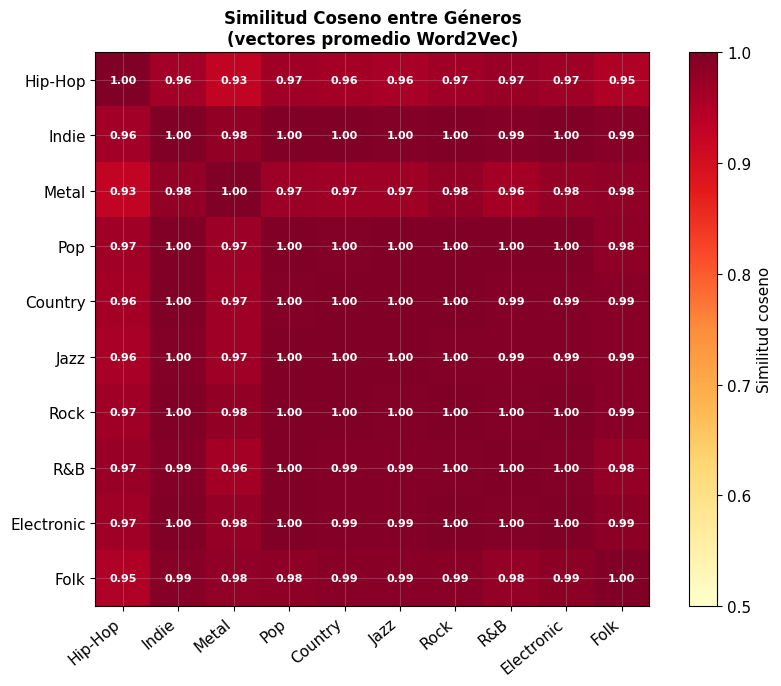

Top 3 pares más SIMILARES semánticamente:
  Indie ↔ Rock: 0.9994
  Pop ↔ R&B: 0.9984
  Rock ↔ Electronic: 0.9983

Top 3 pares más DIFERENTES:
  Hip-Hop ↔ Jazz: 0.9585
  Hip-Hop ↔ Folk: 0.9497
  Hip-Hop ↔ Metal: 0.9278


In [16]:
# ── Similitud entre géneros (vectores promedio) ───────────────────────────────
print('=== Similitud entre géneros (vector promedio por género) ===\n')

def vector_genero(genero: str, modelo: Word2Vec, df_base: pd.DataFrame) -> np.ndarray:
    """Vector promedio de todas las canciones de un género."""
    letras = df_base[df_base['Genre'] == genero]['Lyrics'].tolist()
    vecs = []
    for letra in letras:
        tokens = tokenizar(letra)
        tvecs = [modelo.wv[t] for t in tokens if t in modelo.wv]
        if tvecs:
            vecs.append(np.mean(tvecs, axis=0))
    return np.mean(vecs, axis=0) if vecs else np.zeros(modelo.vector_size)

generos_corpus = df['Genre'].unique().tolist()
vecs_genero = {g: vector_genero(g, w2v_sg, df) for g in generos_corpus}

# Matriz de similitud
n = len(generos_corpus)
sim_generos = np.zeros((n, n))
for i, g1 in enumerate(generos_corpus):
    for j, g2 in enumerate(generos_corpus):
        sim_generos[i, j] = 1 - cosine(vecs_genero[g1], vecs_genero[g2])

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(sim_generos, cmap='YlOrRd', vmin=0.5, vmax=1.0)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(generos_corpus, rotation=40, ha='right')
ax.set_yticklabels(generos_corpus)
ax.set_title('Similitud Coseno entre Géneros\n(vectores promedio Word2Vec)', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Similitud coseno')

for i in range(n):
    for j in range(n):
        color = 'white' if sim_generos[i,j] > 0.85 else 'black'
        ax.text(j, i, f'{sim_generos[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGS / 'similitud_generos_w2v.png', dpi=130, bbox_inches='tight')
plt.show()

# Pares más similares y menos similares
pares = []
for i in range(n):
    for j in range(i+1, n):
        pares.append((generos_corpus[i], generos_corpus[j], sim_generos[i,j]))

pares.sort(key=lambda x: -x[2])
print('Top 3 pares más SIMILARES semánticamente:')
for g1, g2, s in pares[:3]:
    print(f'  {g1} ↔ {g2}: {s:.4f}')
print('\nTop 3 pares más DIFERENTES:')
for g1, g2, s in pares[-3:]:
    print(f'  {g1} ↔ {g2}: {s:.4f}')

## Comparación BoW vs Word2Vec vs BERT

In [17]:
# ── Generar las 4 representaciones sobre la muestra ──────────────────────────

# 1. TF-IDF (BoW)
print('Generando TF-IDF...')
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', min_df=2)
X_tfidf = tfidf.fit_transform(LYRICS).toarray()
print(f'  TF-IDF: {X_tfidf.shape}')

# 2. Word2Vec CBOW (promedio de tokens)
def w2v_promedio(tokens: list, modelo: Word2Vec) -> np.ndarray:
    vecs = [modelo.wv[t] for t in tokens if t in modelo.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(modelo.vector_size)

print('Generando vectores Word2Vec CBOW...')
X_cbow = np.array([w2v_promedio(t, w2v_cbow) for t in sample_tokens])
print(f'  W2V CBOW: {X_cbow.shape}')

# 3. Word2Vec Skip-Gram
print('Generando vectores Word2Vec Skip-Gram...')
X_sg = np.array([w2v_promedio(t, w2v_sg) for t in sample_tokens])
print(f'  W2V SG:   {X_sg.shape}')

# 4. BERT (ya generados)
print(f'  BERT:     {bert_embs.shape}')

REPRESENTACIONES = {
    'TF-IDF (BoW)':        X_tfidf,
    'Word2Vec CBOW':       X_cbow,
    'Word2Vec Skip-Gram':  X_sg,
    'BERT [CLS]':          bert_embs,
}

print('\n Todas las representaciones listas')

Generando TF-IDF...
  TF-IDF: (1000, 5000)
Generando vectores Word2Vec CBOW...
  W2V CBOW: (1000, 100)
Generando vectores Word2Vec Skip-Gram...
  W2V SG:   (1000, 100)
  BERT:     (1000, 768)

✅ Todas las representaciones listas


In [18]:
# ── Clasificación de género (Logistic Regression) ─────────────────────────────
from sklearn.metrics import classification_report

print('=== Clasificación de Género — Logistic Regression ===\n')
clf_acc = {}
clf_reports = {}

for nombre, X in REPRESENTACIONES.items():
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sc, LABELS, test_size=0.25, random_state=42, stratify=LABELS
    )
    clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    clf.fit(X_tr, y_tr)
    acc = clf.score(X_te, y_te)
    clf_acc[nombre] = acc
    clf_reports[nombre] = classification_report(
        y_te, clf.predict(X_te), target_names=le.classes_, output_dict=True
    )
    print(f'  {nombre:<25s}: accuracy = {acc:.4f} ({acc*100:.1f}%)')

mejor_clf = max(clf_acc, key=clf_acc.get)
print(f'\n Mejor clasificador: {mejor_clf} ({clf_acc[mejor_clf]:.4f})')

=== Clasificación de Género — Logistic Regression ===

  TF-IDF (BoW)             : accuracy = 0.2600 (26.0%)
  Word2Vec CBOW            : accuracy = 0.3120 (31.2%)
  Word2Vec Skip-Gram       : accuracy = 0.2720 (27.2%)
  BERT [CLS]               : accuracy = 0.2800 (28.0%)

🏆 Mejor clasificador: Word2Vec CBOW (0.3120)


In [19]:

n_clusters = len(generos_validos)
print(f'=== Clustering K-Means (k={n_clusters}) + Silhouette Score ===\n')

sil_scores = {}
for nombre, X in REPRESENTACIONES.items():
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X)

    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_sc)
    sil = silhouette_score(X_sc, cluster_labels)
    sil_scores[nombre] = sil
    print(f'  {nombre:<25s}: Silhouette = {sil:.4f}')

mejor_sil = max(sil_scores, key=sil_scores.get)
print(f'\n Mejor clustering: {mejor_sil} ({sil_scores[mejor_sil]:.4f})')
print('   (Silhouette → 1.0 = clusters perfectos, 0 = solapados, negativo = mal asignados)')

=== Clustering K-Means (k=10) + Silhouette Score ===

  TF-IDF (BoW)             : Silhouette = -0.0622
  Word2Vec CBOW            : Silhouette = 0.0326
  Word2Vec Skip-Gram       : Silhouette = 0.0207
  BERT [CLS]               : Silhouette = 0.0289

🏆 Mejor clustering: Word2Vec CBOW (0.0326)
   (Silhouette → 1.0 = clusters perfectos, 0 = solapados, negativo = mal asignados)


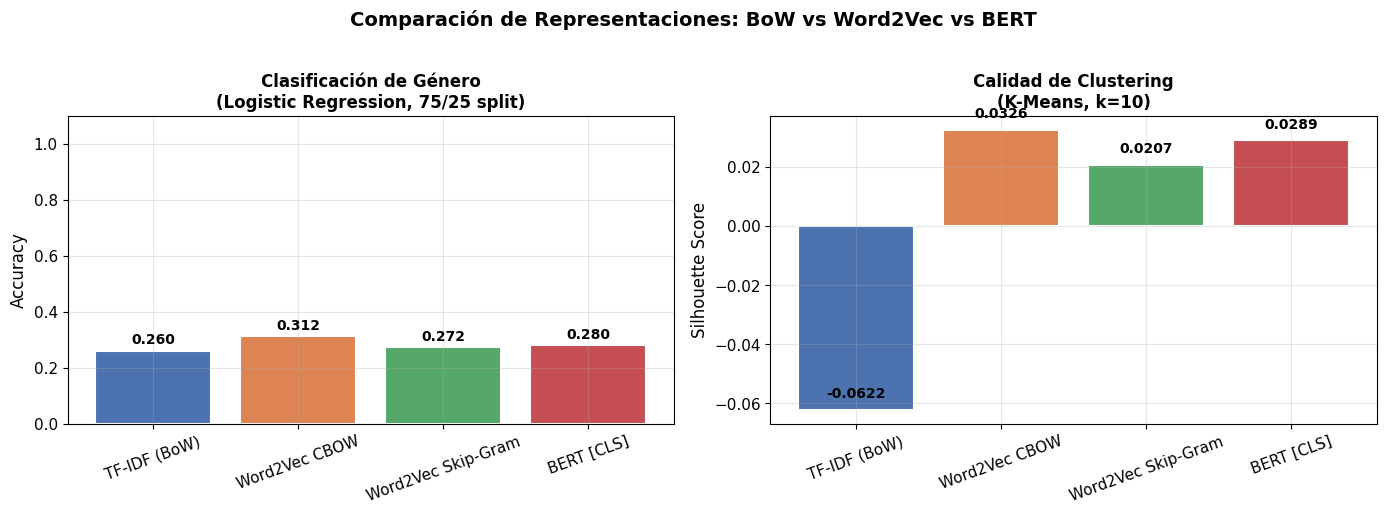

In [20]:
# ── Gráfico comparativo ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
nombres   = list(clf_acc.keys())
colores   = PALETTE[:len(nombres)]

# Clasificación
accs = [clf_acc[n] for n in nombres]
bars = axes[0].bar(nombres, accs, color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Clasificación de Género\n(Logistic Regression, 75/25 split)', fontweight='bold', fontsize=12)
axes[0].tick_params(axis='x', rotation=20)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                f'{acc:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Clustering
sils = [sil_scores[n] for n in nombres]
bars2 = axes[1].bar(nombres, sils, color=colores, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title(f'Calidad de Clustering\n(K-Means, k={n_clusters})', fontweight='bold', fontsize=12)
axes[1].tick_params(axis='x', rotation=20)
for bar, sil in zip(bars2, sils):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{sil:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Comparación de Representaciones: BoW vs Word2Vec vs BERT',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'comparacion_representaciones.png', dpi=130, bbox_inches='tight')
plt.show()

##  Resumen final

In [22]:
print('=' * 65)
print('  RESUMEN: Análisis Semántico — Proyecto 2')
print('=' * 65)
print(f'  Corpus analizado : {len(df_sample):,} canciones  ({len(generos_validos)} géneros)')
print(f'  Modelo BERT      : {MODEL_NAME}')
print(f'  Dispositivo      : {DEVICE}')
print()
print('  CLASIFICACIÓN DE GÉNERO (Logistic Regression):')
for n, acc in sorted(clf_acc.items(), key=lambda x: -x[1]):
    star = '' if n == mejor_clf else '  '
    bar  = '' * int(acc * 20)
    print(f'  {star} {n:<25s} {acc:.4f}  {bar}')

print()
print('  CLUSTERING K-MEANS (Silhouette Score):')
for n, sil in sorted(sil_scores.items(), key=lambda x: -x[1]):
    star = '' if n == mejor_sil else '  '
    bar  = '' * max(0, int(sil * 40))
    print(f'  {star} {n:<25s} {sil:.4f}  {bar}')

print()
print('  ARCHIVOS GENERADOS:')
for f in sorted(FIGS.glob('*.png')):
    print(f'    {f.name}')
for f in sorted(MODELS.glob('*')):
    print(f'    {f.name}')

print()
print('  CONCLUSIONES CLAVE:')
print('  • BERT captura POLISEMIA: la misma palabra tiene vectores')
print('    distintos según el género/contexto donde aparece')
print('  • MLM revela el vocabulario esperado por BERT en cada género')
print('  • La búsqueda semántica recupera canciones temáticamente')
print('    similares sin necesidad de palabras exactas')
print('  • BoW es fuerte para alta dimensión con pocos datos')
print('  • W2V captura relaciones semánticas estáticas (analogías)')
print('  • BERT produce los embeddings más ricos pero es más lento')
print('=' * 65)

  RESUMEN: Análisis Semántico — Proyecto 2
  Corpus analizado : 1,000 canciones  (10 géneros)
  Modelo BERT      : bert-base-uncased
  Dispositivo      : cpu

  CLASIFICACIÓN DE GÉNERO (Logistic Regression):
  🥇 Word2Vec CBOW             0.3120  ██████
     BERT [CLS]                0.2800  █████
     Word2Vec Skip-Gram        0.2720  █████
     TF-IDF (BoW)              0.2600  █████

  CLUSTERING K-MEANS (Silhouette Score):
  🥇 Word2Vec CBOW             0.0326  █
     BERT [CLS]                0.0289  █
     Word2Vec Skip-Gram        0.0207  
     TF-IDF (BoW)              -0.0622  

  ARCHIVOS GENERADOS:
    📊 comparacion_representaciones.png
    📊 corpus_final_stats.png
    📊 mlm_bert_generos.png
    📊 polisemia_bert.png
    📊 scraping_stats.png
    📊 similitud_generos_w2v.png
    💾 bert_corpus_sample.csv
    💾 bert_embeddings.npy
    💾 w2v_cbow.model
    💾 w2v_skipgram.model

  CONCLUSIONES CLAVE:
  • BERT captura POLISEMIA: la misma palabra tiene vectores
    distintos según el g